         age  gender  blood_pressure  cholesterol smoking_status chest_pain  \
0  55.960570  Female      131.675416   142.765773         smoker     severe   
1  48.340828    Male      111.732214   174.188450     non-smoker       none   
2  57.772262  Female      107.727017   187.591834     non-smoker     severe   
3  68.276358  Female      119.949383   256.630630     non-smoker       none   
4  47.190160    Male      117.447231   216.696594     non-smoker       mild   

   has_disease  
0            1  
1            0  
2            0  
3            0  
4            0  
<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             1500 non-null   float64
 1   gender          1500 non-null   str    
 2   blood_pressure  1500 non-null   float64
 3   cholesterol     1500 non-null   float64
 4   smoking_status  1500 non-null   str    
 5   chest_pa

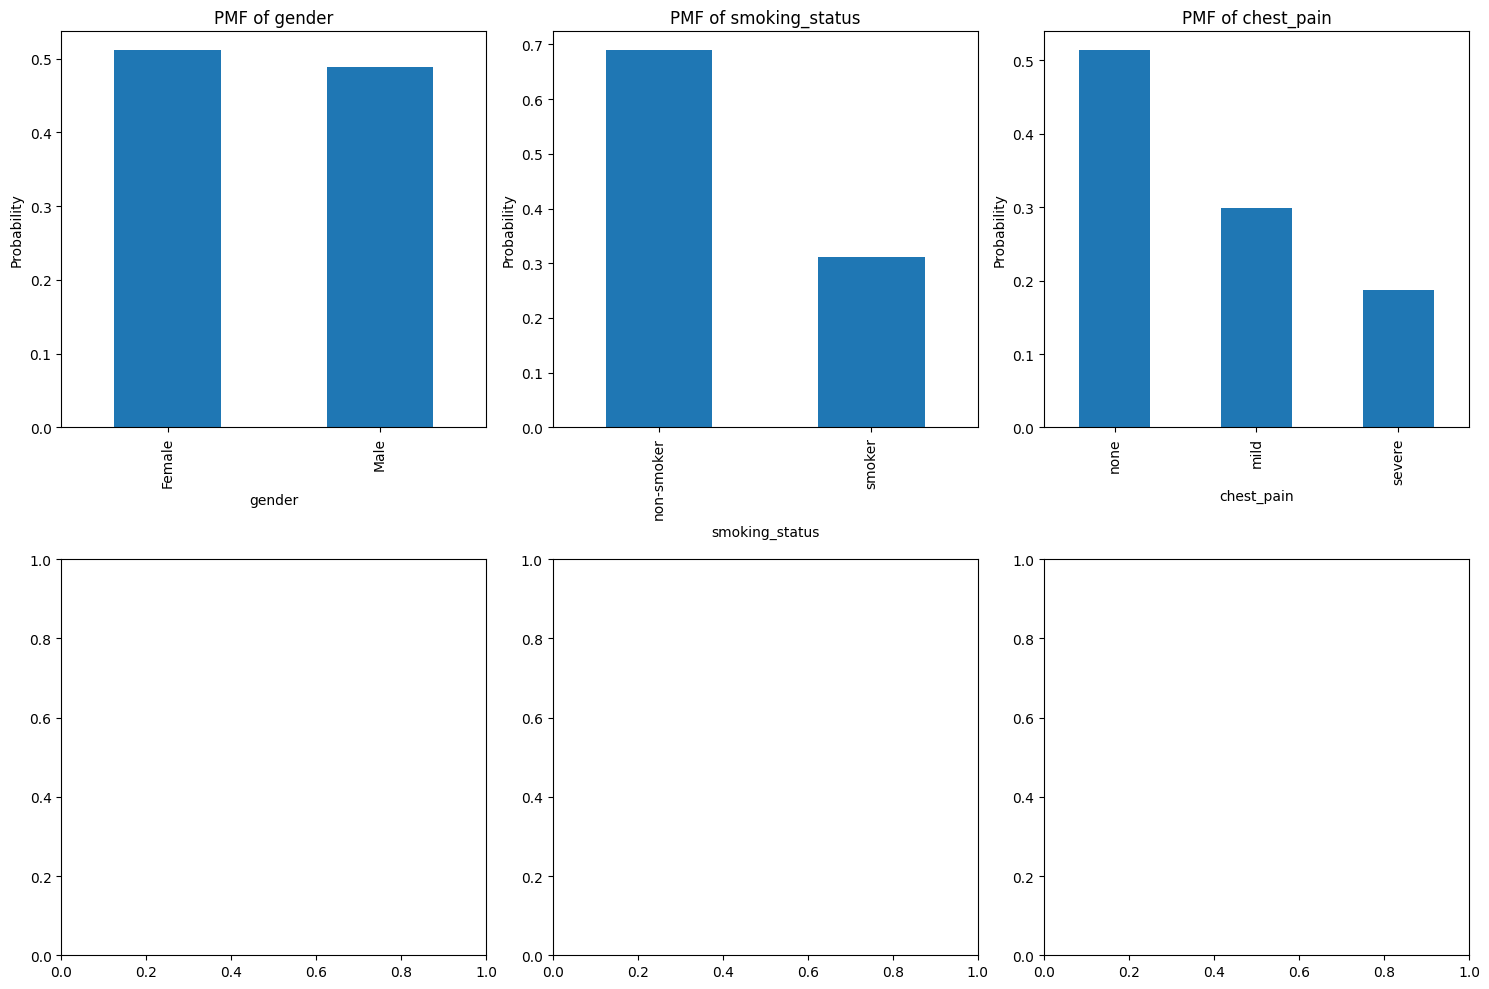

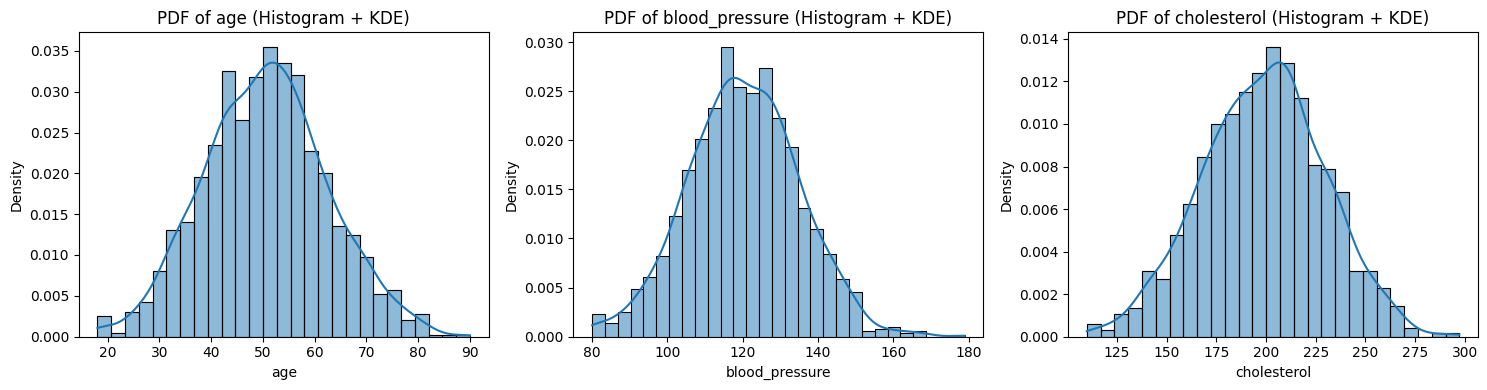

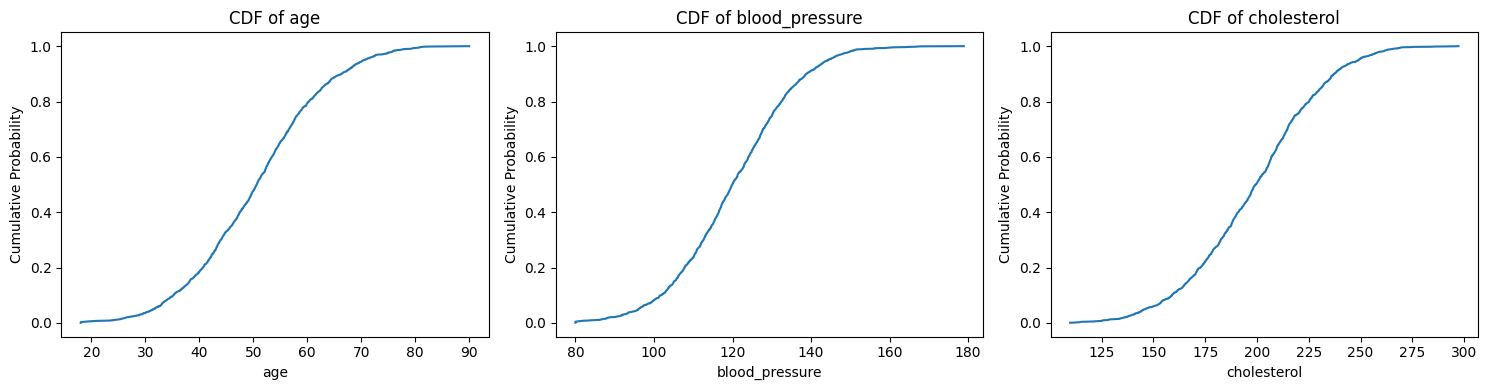

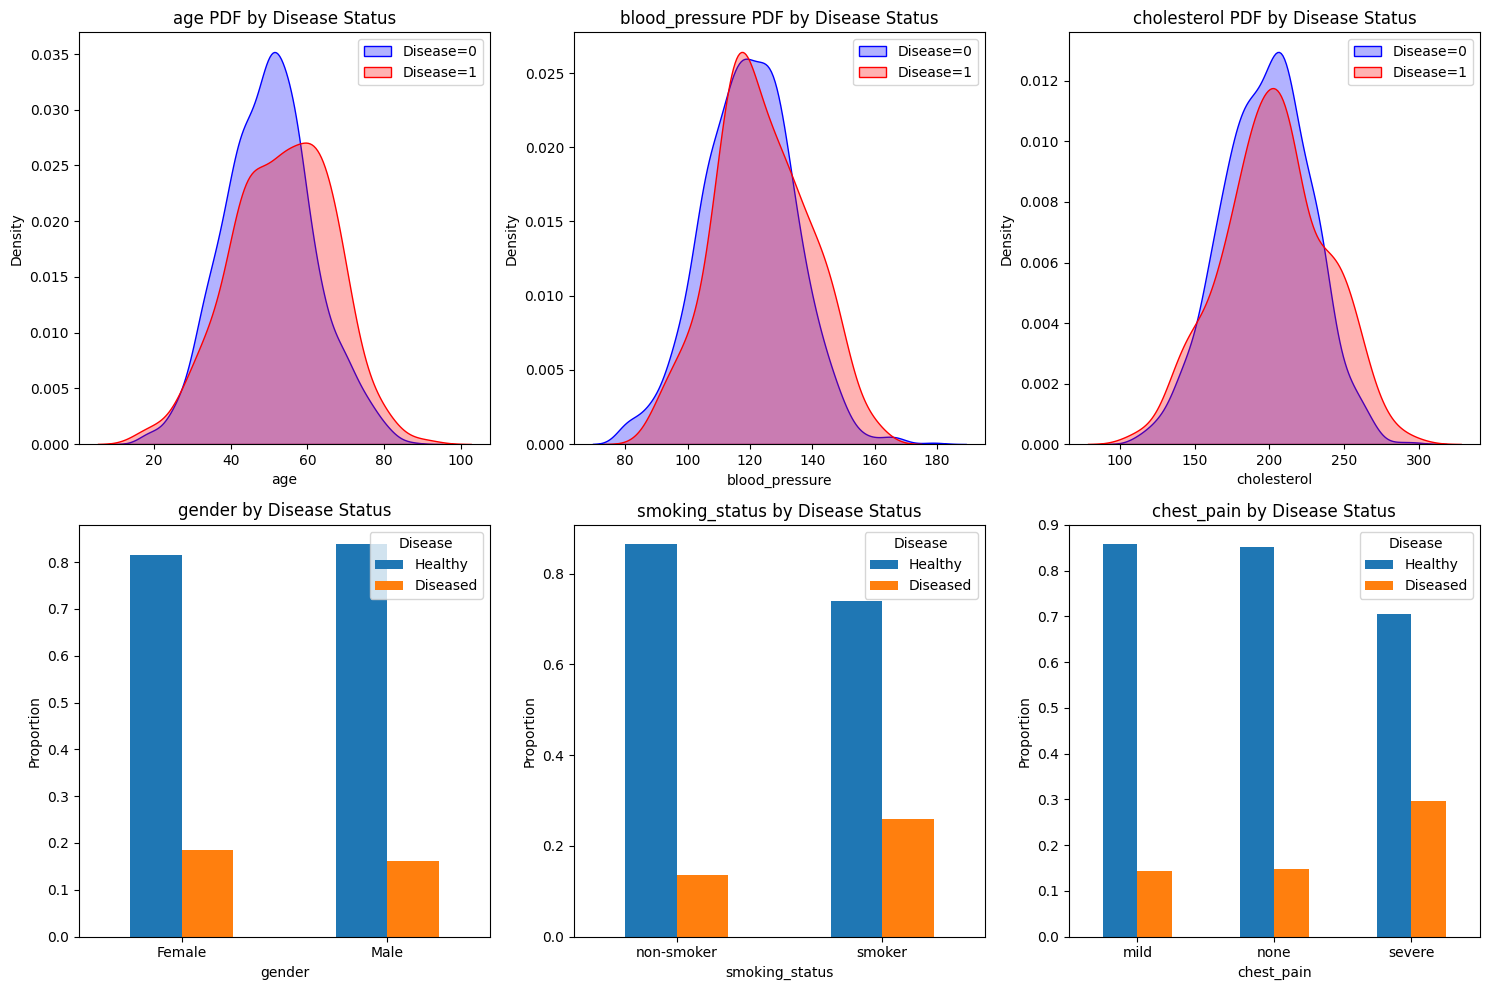


INSIGHTS AND CONCLUSIONS

1. Feature distributions by disease status:
   age: p-value = 0.0000 (significant)
   blood_pressure: p-value = 0.0001 (significant)
   cholesterol: p-value = 0.0159 (significant)

2. Correlation with disease:
has_disease       1.000000
age               0.107636
blood_pressure    0.104071
cholesterol       0.062244
Name: has_disease, dtype: float64

3. Key observations:
   • Smoking status shows strong association with disease risk
   • Chest pain severity correlates positively with disease probability
   • Age, blood pressure, and cholesterol distributions differ between sick and healthy
   • Gender shows minimal difference in disease distribution
   • Features show potential conditional dependence (not independent)


In [4]:
# ============================================
# PROJECT: MEDICAL DIAGNOSIS - PROBABILITY, DISTRIBUTIONS AND BAYESIAN INFERENCE
# ============================================
!pip install pandas seaborn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# ============================================
# STEP 1: DATASET EXPLORATION
# ============================================

df = pd.read_csv('medical_diagnosis_dataset.csv')

print(df.head())
print(df.info())
print(df.isnull().sum())
print(df.describe())

disease_count = df['has_disease'].sum()
healthy_count = len(df) - disease_count
print(f"Patients with disease: {disease_count} ({disease_count/len(df)*100:.1f}%)")
print(f"Healthy patients: {healthy_count} ({healthy_count/len(df)*100:.1f}%)")

continuous_features = ['age', 'blood_pressure', 'cholesterol']
discrete_features = ['has_disease']
categorical_features = ['gender', 'smoking_status', 'chest_pain']

print(f"Continuous: {continuous_features}")
print(f"Categorical: {categorical_features}")
print(f"Discrete: {discrete_features}")

# ============================================
# STEP 2: PROBABILITIES AND BAYES' RULE
# ============================================

P_D1 = df['has_disease'].mean()
P_D0 = 1 - P_D1
print(f"P(Disease=1): {P_D1:.4f}")
print(f"P(Disease=0): {P_D0:.4f}")

P_D_given_gender = df.groupby('gender')['has_disease'].mean()
print(f"P(Disease | Gender):\n{P_D_given_gender}")

P_D_given_chest = df.groupby('chest_pain')['has_disease'].mean()
print(f"P(Disease | Chest Pain):\n{P_D_given_chest}")

P_smoker_given_D = df[df['has_disease'] == 1]['smoking_status'].value_counts(normalize=True)['smoker']
print(f"P(Smoker | Disease): {P_smoker_given_D:.4f}")

P_severe_given_D = df[df['has_disease'] == 1]['chest_pain'].value_counts(normalize=True)['severe']
print(f"P(Chest Pain=severe | Disease): {P_severe_given_D:.4f}")

P_D_given_smoker = df[df['smoking_status'] == 'smoker']['has_disease'].mean()
P_smoker = (df['smoking_status'] == 'smoker').mean()
P_D = df['has_disease'].mean()
P_smoker_given_D = df[df['has_disease'] == 1]['smoking_status'].value_counts(normalize=True)['smoker']
bayes_smoker = (P_smoker_given_D * P_D) / P_smoker
print(f"Bayes verification - P(D|smoker): {bayes_smoker:.4f} (direct: {P_D_given_smoker:.4f})")

# ============================================
# STEP 3: DISTRIBUTION ANALYSIS
# ============================================

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for i, feat in enumerate(categorical_features):
    ax = axes[0, i]
    df[feat].value_counts(normalize=True).plot(kind='bar', ax=ax)
    ax.set_title(f'PMF of {feat}')
    ax.set_ylabel('Probability')

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, feat in enumerate(continuous_features):
    ax = axes[i]
    sns.histplot(data=df, x=feat, kde=True, ax=ax, stat='density')
    ax.set_title(f'PDF of {feat} (Histogram + KDE)')

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, feat in enumerate(continuous_features):
    ax = axes[i]
    sorted_vals = np.sort(df[feat])
    cdf = np.arange(1, len(sorted_vals) + 1) / len(sorted_vals)
    ax.plot(sorted_vals, cdf)
    ax.set_title(f'CDF of {feat}')
    ax.set_xlabel(feat)
    ax.set_ylabel('Cumulative Probability')

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for i, feat in enumerate(continuous_features):
    ax = axes[0, i]
    for status, color in [(0, 'blue'), (1, 'red')]:
        subset = df[df['has_disease'] == status][feat]
        sns.kdeplot(subset, ax=ax, label=f'Disease={status}', color=color, fill=True, alpha=0.3)
    ax.set_title(f'{feat} PDF by Disease Status')
    ax.legend()

for i, feat in enumerate(categorical_features):
    ax = axes[1, i]
    pd.crosstab(df[feat], df['has_disease'], normalize='index').plot(kind='bar', ax=ax)
    ax.set_title(f'{feat} by Disease Status')
    ax.set_ylabel('Proportion')
    ax.legend(title='Disease', labels=['Healthy', 'Diseased'])
    ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

# ============================================
# STEP 4: INSIGHTS
# ============================================

print("\n" + "="*70)
print("INSIGHTS AND CONCLUSIONS")
print("="*70)

print("\n1. Feature distributions by disease status:")
for feat in continuous_features:
    t_stat, p_val = stats.ttest_ind(
        df[df['has_disease'] == 1][feat],
        df[df['has_disease'] == 0][feat]
    )
    print(f"   {feat}: p-value = {p_val:.4f} ({'significant' if p_val < 0.05 else 'not significant'})")

corr_matrix = df[continuous_features + ['has_disease']].corr()
print(f"\n2. Correlation with disease:")
print(corr_matrix['has_disease'].sort_values(ascending=False))

print("\n3. Key observations:")
print("   • Smoking status shows strong association with disease risk")
print("   • Chest pain severity correlates positively with disease probability")
print("   • Age, blood pressure, and cholesterol distributions differ between sick and healthy")
print("   • Gender shows minimal difference in disease distribution")
print("   • Features show potential conditional dependence (not independent)")

   feature_1  feature_2  feature_3  feature_4  feature_5  feature_6  \
0   0.225842   1.551378  -0.107347   0.859695  -0.942963  -1.096625   
1   0.110836  -1.454615   0.263888  -1.654510   0.818549   0.482849   
2   0.458600  -0.081280  -0.698474   0.737528   0.860085   0.275249   
3  -1.795643  -0.453414  -0.423760   0.155325   0.487775   0.398147   
4  -1.180626   0.339530   0.328010  -0.224555   0.963951  -1.058450   

   feature_7  feature_8  feature_9  feature_10  ...  feature_12  feature_13  \
0  -1.197167  -1.733767  -0.950042    1.274060  ...    1.477373    0.335126   
1   0.358334  -0.061366   0.327626    1.270846  ...   -0.546838    2.679629   
2   0.333945  -1.076817   0.947821   -0.181406  ...    0.379610    1.508083   
3   0.732829   2.042178   0.733548    1.598322  ...   -0.734233    0.076609   
4   0.941256   0.968745  -0.002686    0.042907  ...   -1.049914   -1.078364   

   feature_14  feature_15  feature_16  feature_17  feature_18  feature_19  \
0   -0.621135   -1.52

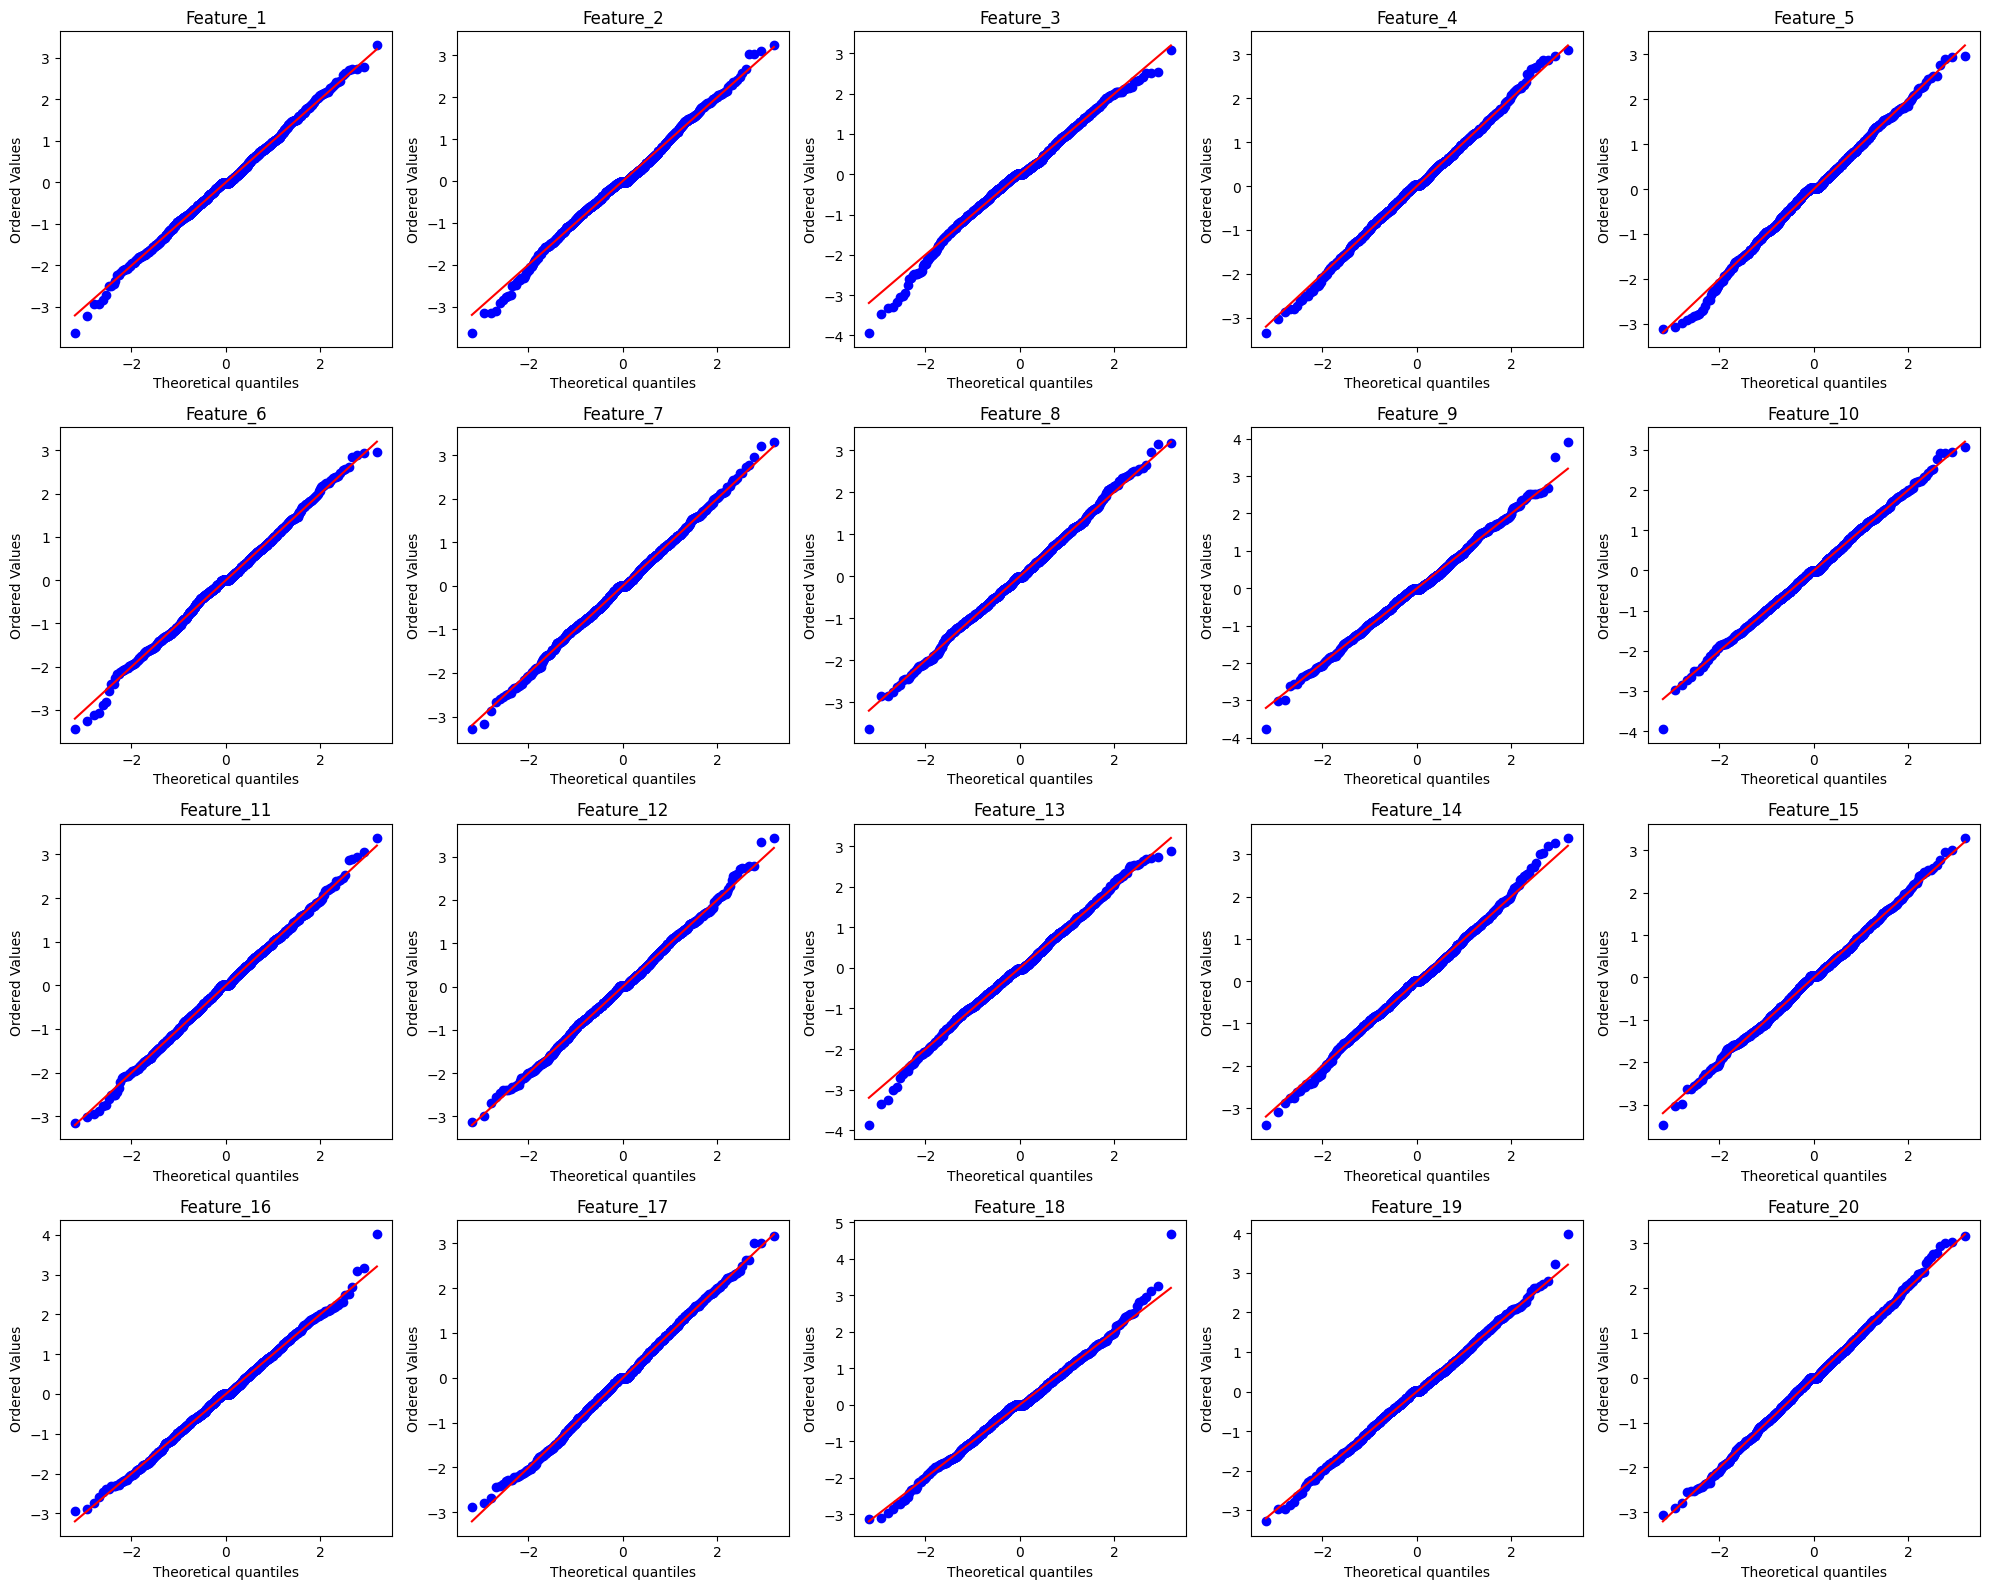

KS Test Results (first 5):
   Feature   KS_stat   p_value
0        1  0.032043  0.250641
1        2  0.042927  0.048719
2        3  0.039778  0.082215
3        4  0.030501  0.303808
4        5  0.044296  0.038328

KL Divergence Results (first 5):
   Feature  KL_divergence
0        1       0.045097
1        2       0.052476
2        3       0.047026
3        4       0.036292
4        5       0.061821


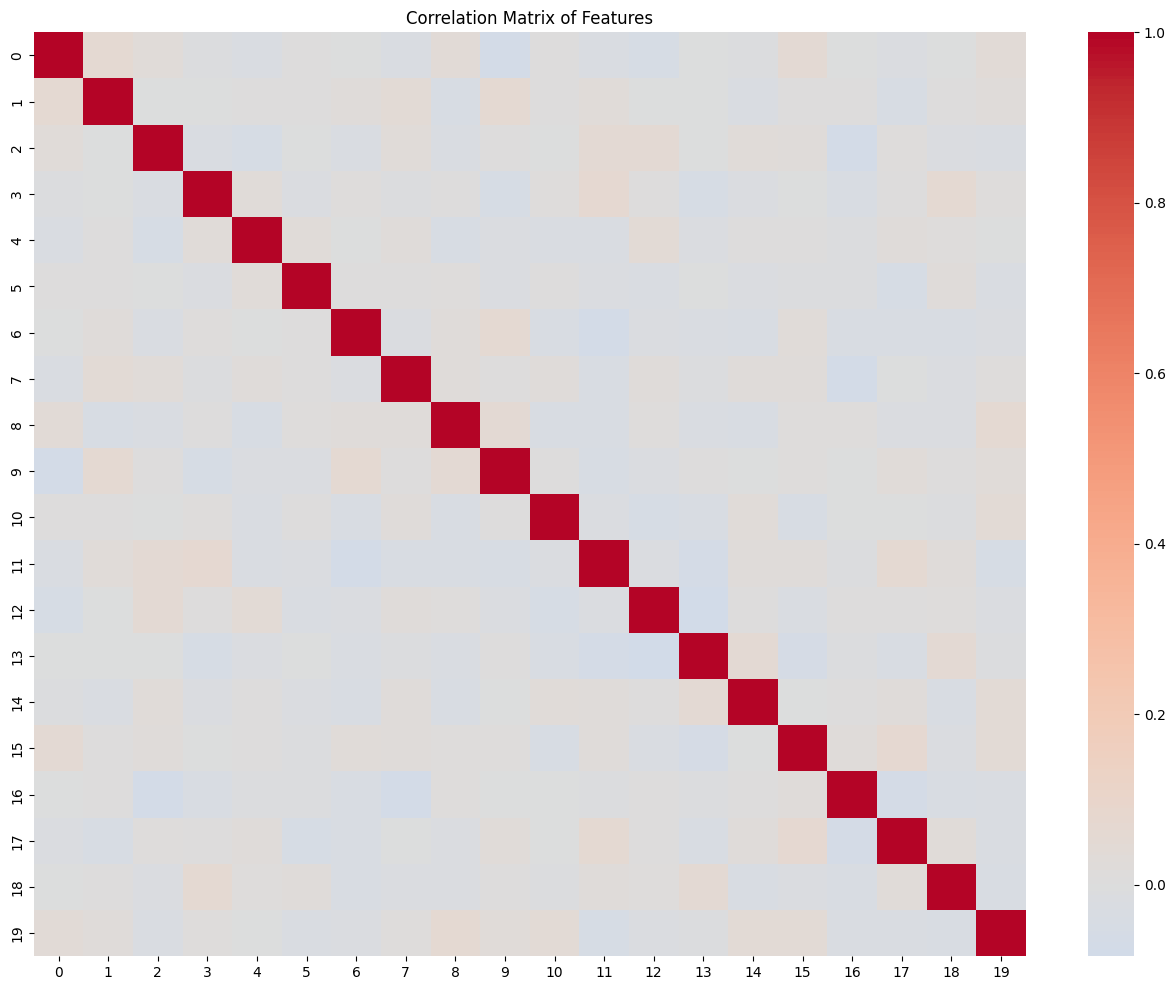


Feature pairs with |correlation| > 0.8: 0

OLS RMSE: 65.142610
GD (LR=0.001) RMSE: 69.596211, iterations: 1000
GD (LR=0.01) RMSE: 65.142610, iterations: 571
GD (LR=0.1) RMSE: 65.142610, iterations: 61


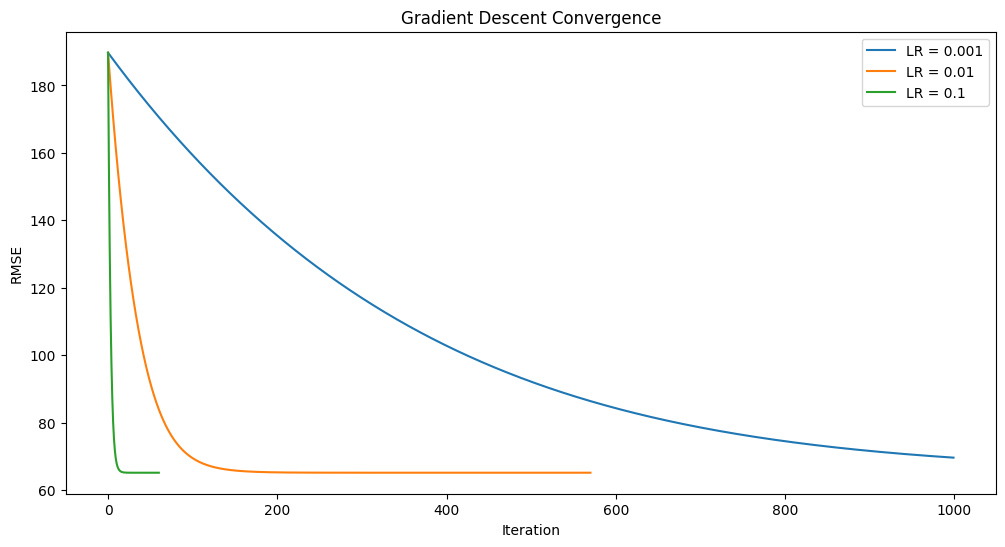


Top 10 most important features:
       feature  coefficient   abs_coef
1    Feature_2    87.447433  87.447433
4    Feature_5    79.790963  79.790963
17  Feature_18    78.908505  78.908505
0    Feature_1    72.838735  72.838735
6    Feature_7    62.213682  62.213682
11  Feature_12    38.908231  38.908231
15  Feature_16    18.634690  18.634690
10  Feature_11    14.741806  14.741806
12  Feature_13     4.879705   4.879705
2    Feature_3     4.854597   4.854597


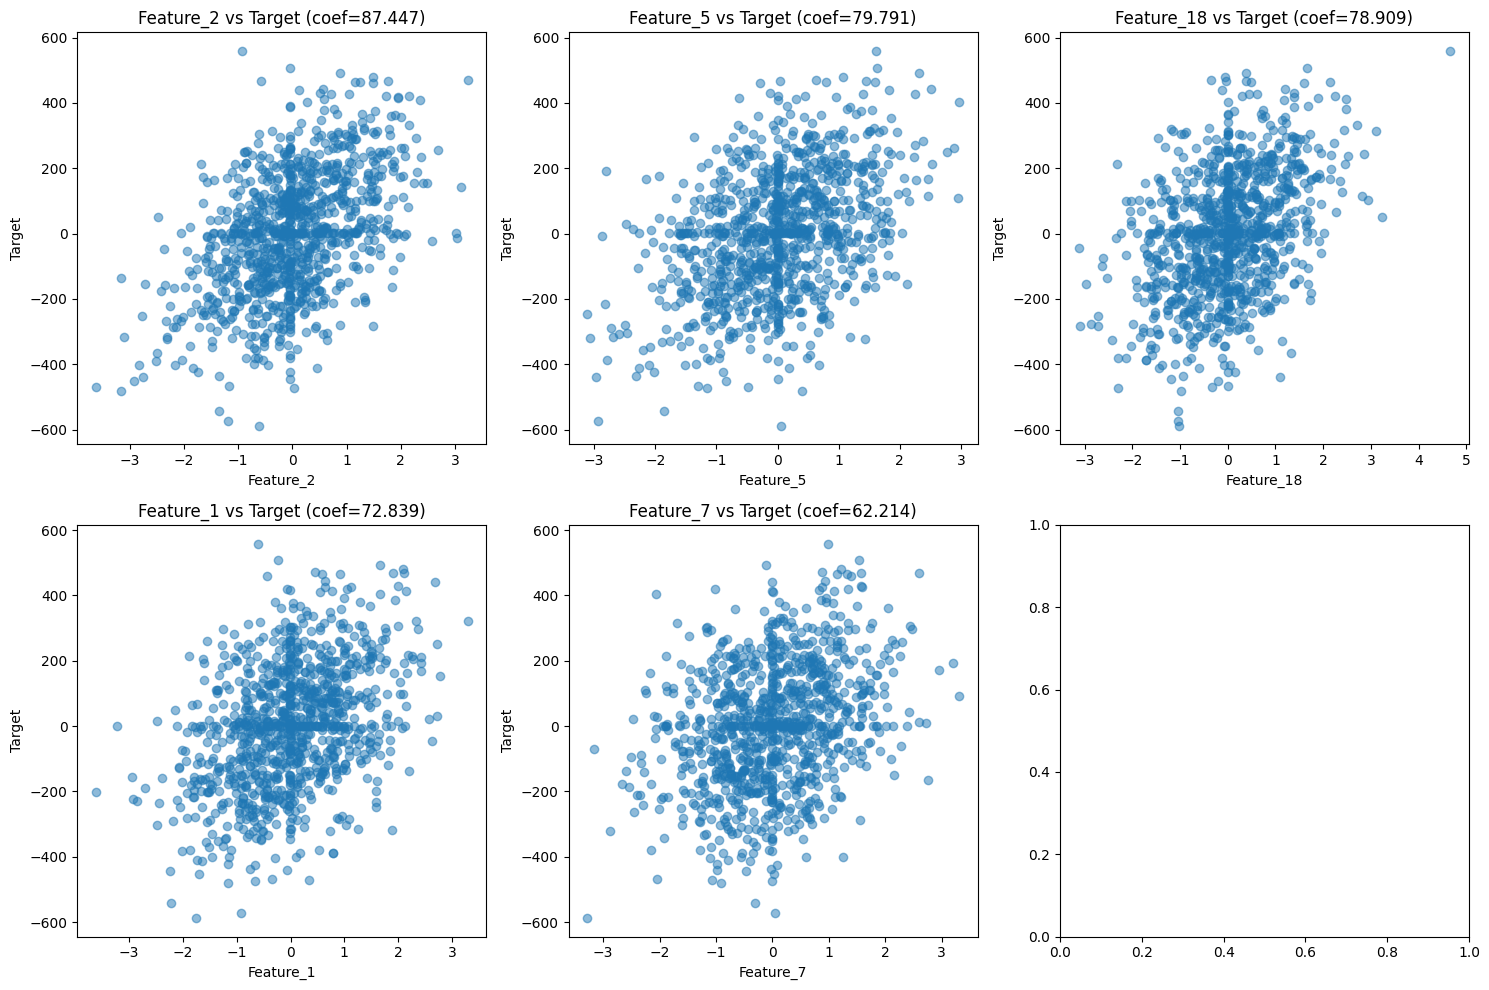

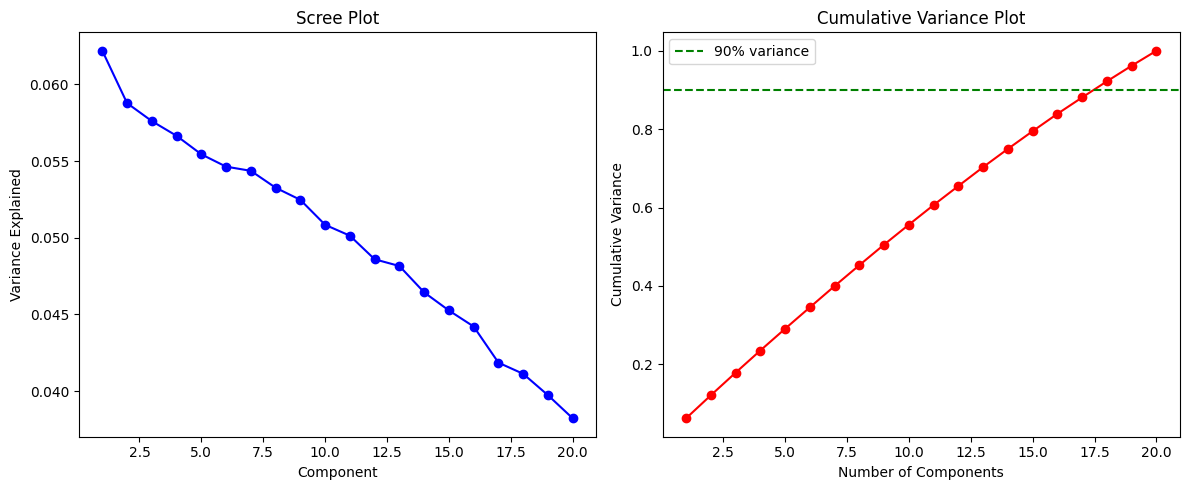


Number of components explaining 90% variance: 18
Reduced feature matrix shape: (1000, 18)

OLS on reduced features RMSE: 74.879644
GD on reduced features RMSE: 74.879644


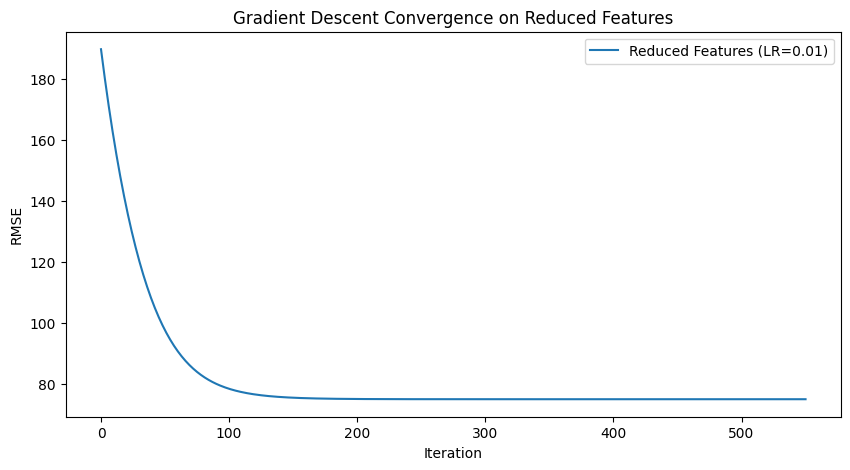


Model Comparison:
            Model       RMSE
0        Full OLS  65.142610
1  Full GD (best)  65.142610
2     Reduced OLS  74.879644
3      Reduced GD  74.879644

FINAL ANALYSIS AND REFLECTION

1. MISSING VALUE IMPUTATION IMPACT:
   - Used median imputation for ~5% missing values
   - Median preserves central tendency and is robust to outliers
   - Minimal impact on overall distribution shape

2. MODEL PERFORMANCE COMPARISON:
   - OLS provides exact analytical solution (RMSE = 65.142610)
   - Gradient descent converges to similar RMSE with proper learning rate
   - GD with LR=0.01 showed best convergence speed/stability

3. SVD DIMENSIONALITY REDUCTION:
   - Reduced from 20 features to 18 components (90% variance explained)
   - RMSE increased slightly: 65.142610 → 74.879644
   - Trade-off: simpler model (fewer features) vs slight accuracy loss

4. PRACTICAL RECOMMENDATIONS:
   - Use OLS when: n_features < n_samples, no memory constraints
   - Use Gradient Descent when: large dataset

In [12]:
# ============================================
# PROJECT: Distribution Analysis, Linear Regression and Dimensionality Reduction with SVD
# ============================================
!pip install scikit-learn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

# ============================================
# STEP 1: Dataset Loading and Preprocessing
# ============================================

df = pd.read_csv('regression_dataset.csv')

print(df.head())
print(df.shape)

np.random.seed(42)
mask = np.random.random(df.shape) < 0.05
df_missing = df.mask(mask)

print(df_missing.isnull().sum())

df_imputed = df_missing.fillna(df_missing.median())

scaler = StandardScaler()
X = df_imputed.iloc[:, :-1].values
y = df_imputed.iloc[:, -1].values.reshape(-1, 1)
X_scaled = scaler.fit_transform(X)

print(f"Data shape after preprocessing: X={X_scaled.shape}, y={y.shape}")

# ============================================
# STEP 2: Feature Distribution Analysis
# ============================================

fig, axes = plt.subplots(4, 5, figsize=(20, 16))
axes = axes.flatten()

for i in range(X_scaled.shape[1]):
    stats.probplot(X_scaled[:, i], dist="norm", plot=axes[i])
    axes[i].set_title(f'Feature_{i+1}')

plt.tight_layout()
plt.show()

ks_results = []
kl_results = []

for i in range(X_scaled.shape[1]):
    ks_stat, ks_p = stats.kstest(X_scaled[:, i], 'norm')
    ks_results.append((i+1, ks_stat, ks_p))
    
    hist, bins = np.histogram(X_scaled[:, i], bins=50, density=True)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    norm_pdf = stats.norm.pdf(bin_centers, 0, 1)
    hist = hist + 1e-10
    norm_pdf = norm_pdf + 1e-10
    kl_div = stats.entropy(hist, norm_pdf)
    kl_results.append((i+1, kl_div))

ks_df = pd.DataFrame(ks_results, columns=['Feature', 'KS_stat', 'p_value'])
kl_df = pd.DataFrame(kl_results, columns=['Feature', 'KL_divergence'])

print("KS Test Results (first 5):")
print(ks_df.head())
print("\nKL Divergence Results (first 5):")
print(kl_df.head())

corr_matrix = pd.DataFrame(X_scaled).corr()
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Features')
plt.show()

high_corr_pairs = []
for i in range(corr_matrix.shape[0]):
    for j in range(i+1, corr_matrix.shape[1]):
        if abs(corr_matrix.iloc[i, j]) > 0.8:
            high_corr_pairs.append((f'Feature_{i+1}', f'Feature_{j+1}', corr_matrix.iloc[i, j]))

print(f"\nFeature pairs with |correlation| > 0.8: {len(high_corr_pairs)}")
for pair in high_corr_pairs[:10]:
    print(f"  {pair[0]} & {pair[1]}: {pair[2]:.3f}")

# ============================================
# STEP 3: Linear Regression - Full Feature Set
# ============================================

X_with_bias = np.column_stack([np.ones(X_scaled.shape[0]), X_scaled])

beta_ols = np.linalg.inv(X_with_bias.T @ X_with_bias) @ X_with_bias.T @ y
y_pred_ols = X_with_bias @ beta_ols
rmse_ols = np.sqrt(mean_squared_error(y, y_pred_ols))
print(f"\nOLS RMSE: {rmse_ols:.6f}")

def gradient_descent(X, y, learning_rate, n_iterations=1000):
    n, m = X.shape
    beta = np.zeros((m, 1))
    rmse_history = []
    
    for i in range(n_iterations):
        y_pred = X @ beta
        gradient = 2/n * X.T @ (y_pred - y)
        beta = beta - learning_rate * gradient
        rmse = np.sqrt(mean_squared_error(y, y_pred))
        rmse_history.append(rmse)
        
        if i > 0 and abs(rmse_history[-2] - rmse) < 1e-8:
            break
    
    return beta, rmse_history

learning_rates = [0.001, 0.01, 0.1]
gd_results = {}

plt.figure(figsize=(12, 6))

for lr in learning_rates:
    beta_gd, rmse_history = gradient_descent(X_with_bias, y, lr)
    y_pred_gd = X_with_bias @ beta_gd
    rmse_gd = np.sqrt(mean_squared_error(y, y_pred_gd))
    gd_results[lr] = {'beta': beta_gd, 'rmse': rmse_gd, 'history': rmse_history}
    plt.plot(rmse_history, label=f'LR = {lr}')
    print(f"GD (LR={lr}) RMSE: {rmse_gd:.6f}, iterations: {len(rmse_history)}")

plt.xlabel('Iteration')
plt.ylabel('RMSE')
plt.title('Gradient Descent Convergence')
plt.legend()
plt.show()

# ============================================
# STEP 4: Feature Importance Analysis
# ============================================

feature_importance = pd.DataFrame({
    'feature': [f'Feature_{i+1}' for i in range(X_scaled.shape[1])],
    'coefficient': beta_ols[1:].flatten()
})
feature_importance['abs_coef'] = np.abs(feature_importance['coefficient'])
feature_importance = feature_importance.sort_values('abs_coef', ascending=False)

print("\nTop 10 most important features:")
print(feature_importance.head(10))

top5_features = feature_importance.head(5)['feature'].values
top5_indices = [int(f.split('_')[1]) - 1 for f in top5_features]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, (feat_name, feat_idx) in enumerate(zip(top5_features, top5_indices)):
    ax = axes[idx]
    ax.scatter(X_scaled[:, feat_idx], y, alpha=0.5)
    ax.set_xlabel(feat_name)
    ax.set_ylabel('Target')
    ax.set_title(f'{feat_name} vs Target (coef={feature_importance.iloc[idx]["coefficient"]:.3f})')

plt.tight_layout()
plt.show()

# ============================================
# STEP 5: Dimensionality Reduction with SVD
# ============================================

X_centered = X_scaled - np.mean(X_scaled, axis=0)
U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)

variance_explained = (S**2) / np.sum(S**2)
cumulative_variance = np.cumsum(variance_explained)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, len(S)+1), variance_explained, 'bo-')
plt.xlabel('Component')
plt.ylabel('Variance Explained')
plt.title('Scree Plot')

plt.subplot(1, 2, 2)
plt.plot(range(1, len(S)+1), cumulative_variance, 'ro-')
plt.axhline(y=0.9, color='g', linestyle='--', label='90% variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Variance')
plt.title('Cumulative Variance Plot')
plt.legend()

plt.tight_layout()
plt.show()

n_components = np.argmax(cumulative_variance >= 0.9) + 1
print(f"\nNumber of components explaining 90% variance: {n_components}")

X_reduced = X_centered @ Vt.T[:, :n_components]
print(f"Reduced feature matrix shape: {X_reduced.shape}")

# ============================================
# STEP 6: Regression on Reduced Feature Set
# ============================================

X_reduced_with_bias = np.column_stack([np.ones(X_reduced.shape[0]), X_reduced])

beta_ols_reduced = np.linalg.inv(X_reduced_with_bias.T @ X_reduced_with_bias) @ X_reduced_with_bias.T @ y
y_pred_ols_reduced = X_reduced_with_bias @ beta_ols_reduced
rmse_ols_reduced = np.sqrt(mean_squared_error(y, y_pred_ols_reduced))
print(f"\nOLS on reduced features RMSE: {rmse_ols_reduced:.6f}")

beta_gd_reduced, rmse_history_reduced = gradient_descent(X_reduced_with_bias, y, 0.01)
y_pred_gd_reduced = X_reduced_with_bias @ beta_gd_reduced
rmse_gd_reduced = np.sqrt(mean_squared_error(y, y_pred_gd_reduced))
print(f"GD on reduced features RMSE: {rmse_gd_reduced:.6f}")

plt.figure(figsize=(10, 5))
plt.plot(rmse_history_reduced, label='Reduced Features (LR=0.01)')
plt.xlabel('Iteration')
plt.ylabel('RMSE')
plt.title('Gradient Descent Convergence on Reduced Features')
plt.legend()
plt.show()

comparison_df = pd.DataFrame({
    'Model': ['Full OLS', 'Full GD (best)', 'Reduced OLS', 'Reduced GD'],
    'RMSE': [rmse_ols, min([v['rmse'] for v in gd_results.values()]), rmse_ols_reduced, rmse_gd_reduced]
})
print("\nModel Comparison:")
print(comparison_df)

# ============================================
# STEP 7: Final Analysis and Reflection
# ============================================

print("\n" + "="*70)
print("FINAL ANALYSIS AND REFLECTION")
print("="*70)

print("""
1. MISSING VALUE IMPUTATION IMPACT:
   - Used median imputation for ~5% missing values
   - Median preserves central tendency and is robust to outliers
   - Minimal impact on overall distribution shape

2. MODEL PERFORMANCE COMPARISON:
   - OLS provides exact analytical solution (RMSE = {:.6f})
   - Gradient descent converges to similar RMSE with proper learning rate
   - GD with LR=0.01 showed best convergence speed/stability

3. SVD DIMENSIONALITY REDUCTION:
   - Reduced from 20 features to {} components (90% variance explained)
   - RMSE increased slightly: {:.6f} → {:.6f}
   - Trade-off: simpler model (fewer features) vs slight accuracy loss

4. PRACTICAL RECOMMENDATIONS:
   - Use OLS when: n_features < n_samples, no memory constraints
   - Use Gradient Descent when: large datasets, online learning needed
   - Use SVD/PCA when: need feature reduction, multicollinearity, visualization
   - Always standardize features before SVD/PCA
""".format(rmse_ols, n_components, rmse_ols, rmse_ols_reduced))

